<a href="https://colab.research.google.com/github/shahruza-078/hello-world/blob/main/240032_Week3_Demo1_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 · Demo 1 — Advanced Cleaning  *(guided, in class)*
### Machine Learning · CAU

**Name(s):** ___Shohruza JUmabayeva___________________ &nbsp;&nbsp; **Date:** __23.09.26________

The lecture explained *why*. Now you do it. This is the full professional clean-up: smart
imputation, outliers, messy text, advanced encoding, and feature engineering.

> **Format:** the instructor **demos** each technique on the **Titanic** (📽️, ~10 min) — watch and
> run along. Then **🎮 Your turn:** do the *same* on a **different dataset, the `mpg` cars data**.
> Same idea, new data. Fill every `____`.

**This is the in-class guided demo.** After each part, do the mpg task while it's fresh. For free experimentation, use the separate **Self-Study Lab** (diamonds).

## 0 — Load both datasets

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

demo = sns.load_dataset("titanic")   # 📽️ instructor
cars = sns.load_dataset("mpg")       # 🎮 you
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

def peek(df, name="data"):
    print(f"🔎 {name}: {df.shape[0]} rows × {df.shape[1]} columns")
    df.info()
    num = df.select_dtypes("number")

    # 1) MISSING VALUES — where are the gaps?
    miss = df.isnull().sum(); miss = miss[miss > 0].sort_values()
    if len(miss):
        plt.figure(figsize=(7, 3)); miss.plot(kind="barh", color="#C97A0A")
        plt.title(f"{name} — missing values per column"); plt.tight_layout(); plt.show()
        plt.figure(figsize=(9, 3.5))
        sns.heatmap(df.isnull(), cbar=False, cmap=sns.color_palette(["#EEF2F4", "#C97A0A"]))
        plt.title(f"{name} — missingness pattern (gold = missing)"); plt.yticks([]); plt.show()
    else:
        print("✅ No missing values.")

    # 2) DISTRIBUTIONS — spot skew before transforming
    num.hist(figsize=(12, 8), bins=30, color="#026873", edgecolor="white")
    plt.suptitle(f"{name} — distributions", y=1.02); plt.tight_layout(); plt.show()
    print("Skew (|>1| = quite skewed):\n", num.skew().round(2).sort_values(ascending=False))

    # 3) OUTLIERS — box plot per numeric column
    n = len(num.columns); cols = 3; rows = -(-n // cols)
    plt.figure(figsize=(cols * 4, rows * 2.6))
    for i, c in enumerate(num.columns, 1):
        plt.subplot(rows, cols, i); sns.boxplot(x=num[c], color="#00A896")
        plt.title(c); plt.xlabel("")
    plt.suptitle(f"{name} — outliers", y=1.02); plt.tight_layout(); plt.show()

    # 4) CATEGORIES — how many of each? (top 15 if high-cardinality)
    for c in df.select_dtypes(include=["object", "category"]).columns:
        vc = df[c].value_counts().head(15)
        plt.figure(figsize=(7, max(2, len(vc) * 0.3)))
        sns.barplot(x=vc.values, y=vc.index.astype(str), color="#F9A03F")
        plt.title(f"{name} — {c}  ({df[c].nunique()} categories)")
        plt.xlabel("count"); plt.tight_layout(); plt.show()

    # 5) CORRELATIONS — which numbers move together?
    plt.figure(figsize=(7, 6))
    sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title(f"{name} — correlations"); plt.tight_layout(); plt.show()

🔎 cars: 398 rows × 9 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


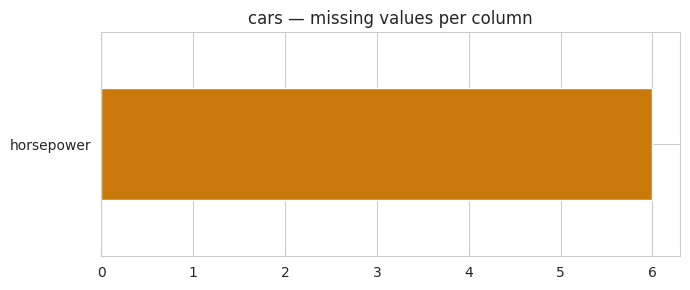

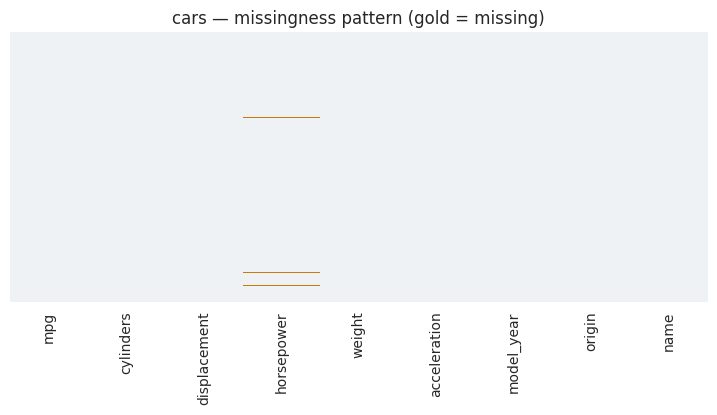

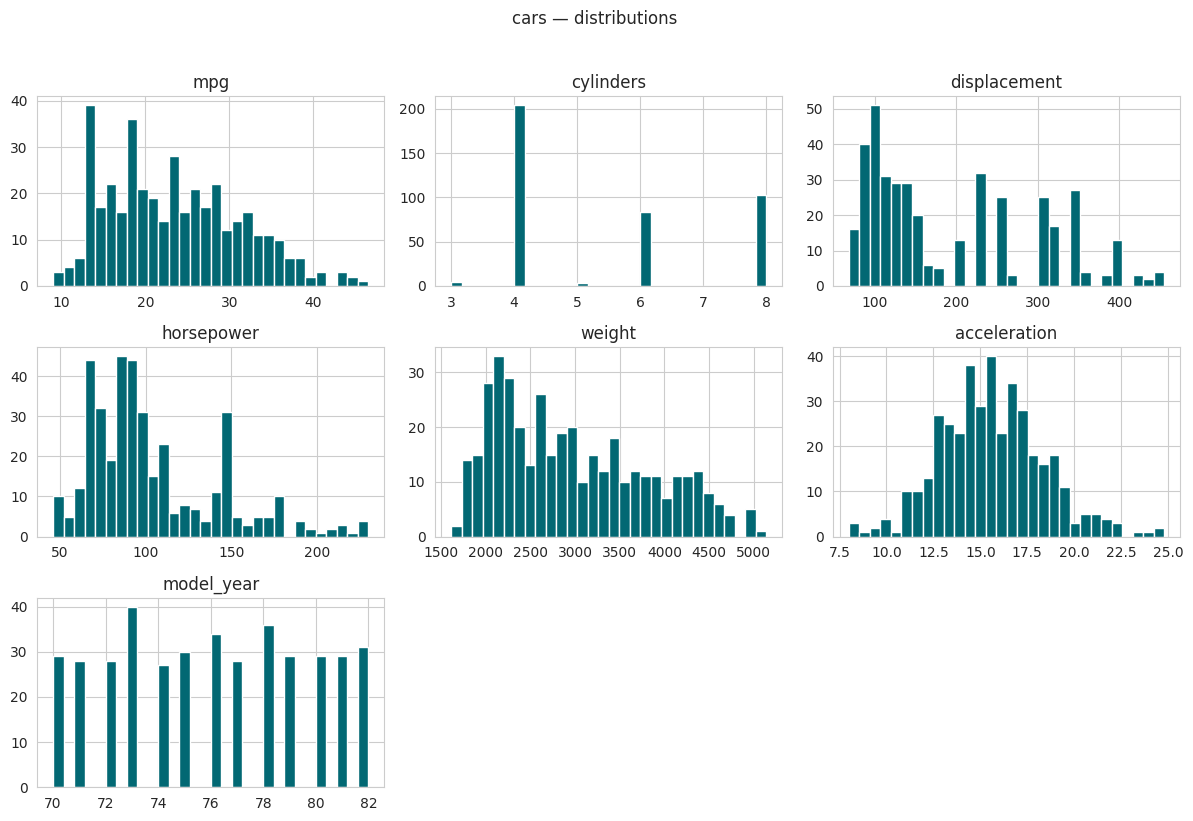

Skew (|>1| = quite skewed):
 horsepower      1.09
displacement    0.72
cylinders       0.53
weight          0.53
mpg             0.46
acceleration    0.28
model_year      0.01
dtype: float64


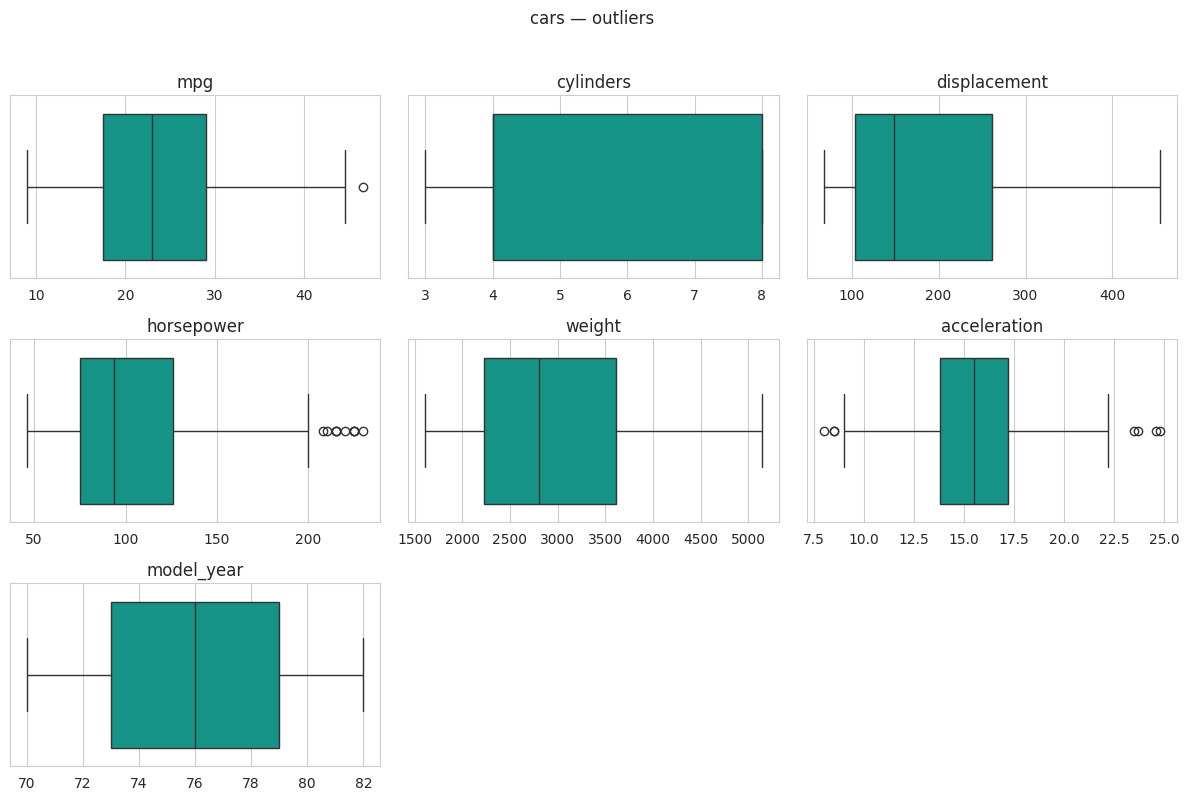

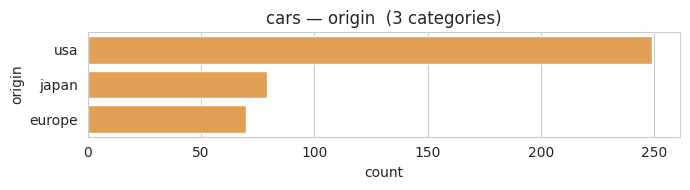

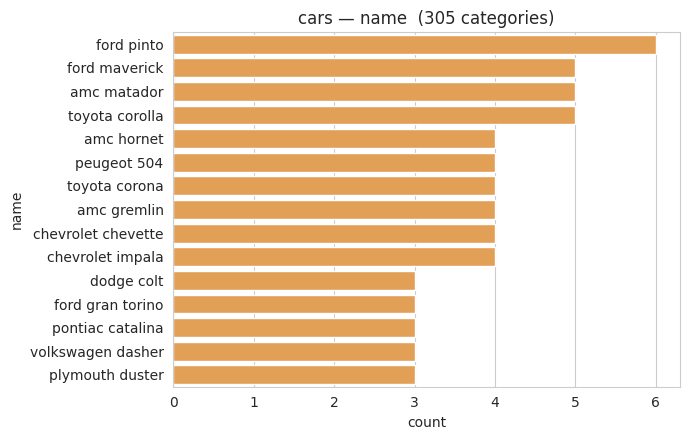

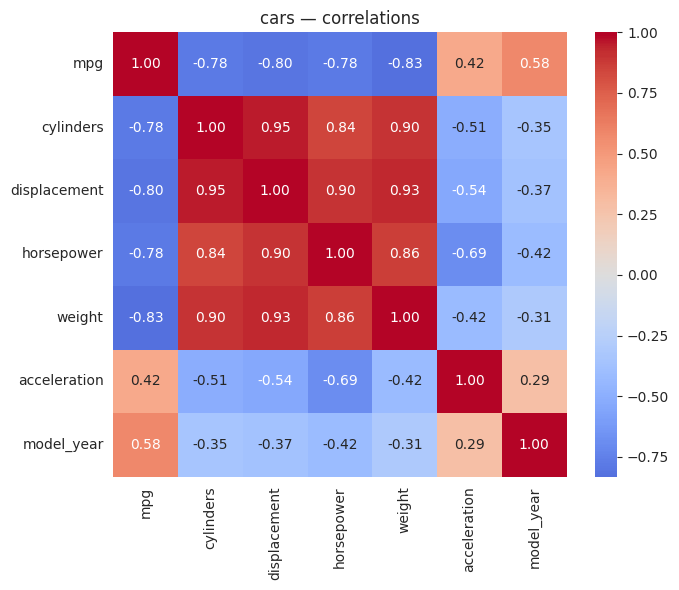

In [ ]:
peek(cars, "cars")   # 📽️ inspect before cleaning

In [ ]:
peek(cars, "Cars")

## 1 — Profile the gaps & remember them
Count missing, then add a **“was it missing?” flag** before filling (the fact can be useful).

### 🎮 Your turn (cars) — flag the missing horsepower

In [ ]:
print("Missing horsepower:", cars["horsepower"].isna().sum())

cars["horsepower_was_missing"] = cars["horsepower"].isna().astype(int)

cars[["horsepower", "horsepower_was_missing"]].head()


## 2 — Advanced imputation with KNN
Instead of one global number, **KNNImputer** fills each gap from the most **similar rows**
(across several numeric columns).

> ⚠️ Strictly, fit the imputer on the **training set only** — you'll do that with a Pipeline in Lab 2.

### 🎮 Your turn (cars) — KNN-impute horsepower

In [ ]:
from sklearn.impute import KNNImputer

knn_cols = ["horsepower", "mpg", "cylinders", "displacement", "weight", "acceleration"]

imputer = KNNImputer(n_neighbors=5)

cars[knn_cols] = imputer.fit_transform(cars[knn_cols])

print("Missing horsepower after KNN:", cars["horsepower"].isna().sum())


## 3 — Outliers & skew
Detect with the **IQR rule**, **cap** the extremes, and **log-transform** a long tail so it's more balanced.

### 🎮 Your turn (cars) — cap horsepower, then log-transform it

In [ ]:
# IQR rule
Q1 = cars["horsepower"].quantile(0.25)
Q3 = cars["horsepower"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("IQR bounds:", lower, upper)

# Cap extreme values
cars["horsepower"] = cars["horsepower"].clip(lower=lower, upper=upper)

# Log-transform
cars["horsepower_log"] = np.log1p(cars["horsepower"])

cars[["horsepower", "horsepower_log"]].head()


## 4 — Duplicates & messy text
Drop exact-duplicate rows, and **standardise text** (strip spaces, fix case).

### 🎮 Your turn (cars) — pull the **brand** out of the car `name`
`name` looks like *“chevrolet chevelle malibu”* — the first word is the brand. Great for a string op
and, next, for encoding.

In [ ]:
# Drop exact duplicate rows
cars = cars.drop_duplicates().copy()

# Clean the car name
cars["name"] = cars["name"].str.strip().str.lower()

# Extract first word = brand
cars["brand"] = cars["name"].str.split().str[0]

cars[["name", "brand"]].head(10)


## 5 — Advanced encoding

**Ordinal** for ordered categories; **one-hot** for unordered.

### 🎮 Your turn (cars) — high-cardinality `brand`
30 brands → 30 one-hot columns is a lot. First **group rare brands into “other”**, then one-hot.

In [ ]:
# Keep brands appearing at least 5 times
brand_counts = cars["brand"].value_counts()

common_brands = brand_counts[brand_counts >= 5].index

cars["brand_grouped"] = cars["brand"].where(
    cars["brand"].isin(common_brands),
    "other"
)

# One-hot encode the grouped brand
cars = pd.get_dummies(
    cars,
    columns=["brand_grouped"],
    prefix="brand",
    dtype=int
)

cars.head()


## 6 — Feature engineering


### 🎮 Your turn (cars) — `car_age` and a `power_to_weight` ratio
(The dataset ends in 1982, so age = 82 − model_year.)

In [ ]:
# Car age: dataset ends in 1982
cars["car_age"] = 82 - cars["model_year"]

# Power-to-weight ratio
cars["power_to_weight"] = cars["horsepower"] / cars["weight"]

cars[["model_year", "car_age", "horsepower", "weight", "power_to_weight"]].head()


## 7 — Save your advanced-cleaned data
### 🎮 Your turn (cars)
Drop the leftover text columns and save.

In [ ]:
# Drop original text columns and intermediate brand column
cars_clean = cars.drop(columns=["name", "brand"])

# Save the cleaned dataset
cars_clean.to_csv("mpg_advanced_cleaned.csv", index=False)

print("✅ Saved:", cars_clean.shape)
cars_clean.head()


### 🏁 Wrap
You did a full professional clean-up on a dataset the instructor never touched. **Next lab:** selection, leakage, and the leak-proof **Pipeline**.